In [16]:
%pip install MiniSom


#Libraries


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

import hdbscan
from hdbscan import HDBSCAN
from minisom import MiniSom

import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#load data

In [18]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DataSets/customer_dataset.csv", encoding='latin1')
df.columns = df.columns.str.lower()
df.head()

,customer_id,age,gender,location,signup_date,transaction_id,transaction_date,amount_spent,product_category,payment_method,transaction_frequency,avg_time_on_site,pages_visited,preferred_product_tags,is_high_value,segment_label
0,C1000,56,Female,Melanieport,2023-10-02,T2000,2025-04-08 04:16:11,21.58,Home,Wallet,10,10.39,7,"home_decor, 5G",0,Occasional_Buyer
1,C1001,46,Male,Amberside,2025-01-22,T2001,2025-04-08 16:46:58,19.01,Fitness,Card,12,6.07,16,"bluetooth, gaming, home_decor, smartphone",0,Occasional_Buyer
2,C1002,32,Female,Lake Sandra,2024-05-18,T2002,2025-04-21 12:53:50,106.56,Home,Wallet,12,7.39,19,"laptop, 5G, organic",1,Occasional_Buyer
3,C1003,60,Male,West Robertfort,2022-12-31,T2003,2025-04-02 18:23:37,30.85,Grocery,Card,4,9.00,14,"eco_friendly, smartphone, gaming",0,Occasional_Buyer
4,C1004,25,Male,South Holly,2024-11-21,T2004,2025-03-29 20:06:45,56.42,Fashion,UPI,4,10.23,22,"laptop, home_decor",1,Occasional_Buyer


In [26]:
numeric_col = df.select_dtypes(include=np.number).columns.tolist()
categorical_col = df.select_dtypes(exclude=np.number).columns.tolist()

print( numeric_col)
print( categorical_col)

['age', 'amount_spent', 'transaction_frequency', 'avg_time_on_site', 'pages_visited', 'is_high_value']
['customer_id', 'gender', 'location', 'signup_date', 'transaction_id', 'transaction_date', 'product_category', 'payment_method', 'preferred_product_tags', 'segment_label']


#Normalize

In [27]:
rfm = df[numeric_col]
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

#MODELS

#KMEANS

In [35]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(rfm_scaled)
df['k_means_label'] = kmeans_labels

#GAUSSIANMIXTURE

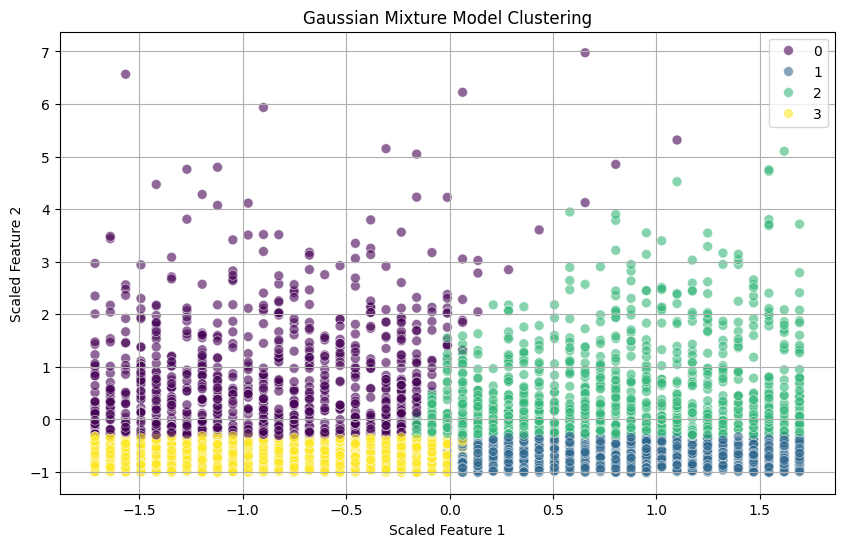

In [54]:
gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(rfm_scaled)
df['gmm_label'] = gmm_labels

#SOM

In [55]:
som = MiniSom(x=5, y=5, input_len=rfm_scaled.shape[1], sigma=0.3, learning_rate=0.5)
som.random_weights_init(rfm_scaled)
som.train_random(rfm_scaled, 200)

def get_som_cluster(x):
    return som.winner(x)

df['SOM_Cluster'] = [get_som_cluster(x) for x in rfm_scaled]
df['SOM_Cluster'] = df['SOM_Cluster'].apply(lambda x: f"{x[0]}-{x[1]}")


#HDBSCAN

In [60]:
hdbscan_model = HDBSCAN(min_cluster_size=5, metric='euclidean', cluster_selection_method='eom')
df['hdbscan_label'] = hdbscan_model.fit_predict(rfm_scaled)

#UserInput

In [69]:
age = float(input("Enter Age: "))
amount_spent = float(input("Enter Amount Spent: "))
transaction_frequency = float(input("Enter Transaction Frequency: "))
avg_time_on_site = float(input("Enter Average Time on Site: "))
pages_visited = float(input("Enter Pages Visited: "))
is_high_value = float(input("Enter Is High Value (0 or 1): "))

input_data = [[age, amount_spent, transaction_frequency, avg_time_on_site, pages_visited, is_high_value]]
input_scaled = scaler.transform(input_data)

#Prediction
kmeans_pred = kmeans.predict(input_scaled)[0]
gmm_pred = gmm.predict(input_scaled)[0]
som_pred = get_som_cluster(input_scaled[0])
som_cluster = f"{som_pred[0]}-{som_pred[1]}"

print("\nSegmentation Result for Input:")
print(f"KMeans Segment: {kmeans_pred}")
print(f"GMM Segment: {gmm_pred}")
print(f"SOM Segment: {som_cluster}")

KeyboardInterrupt: Interrupted by user

#Visualizing PCA

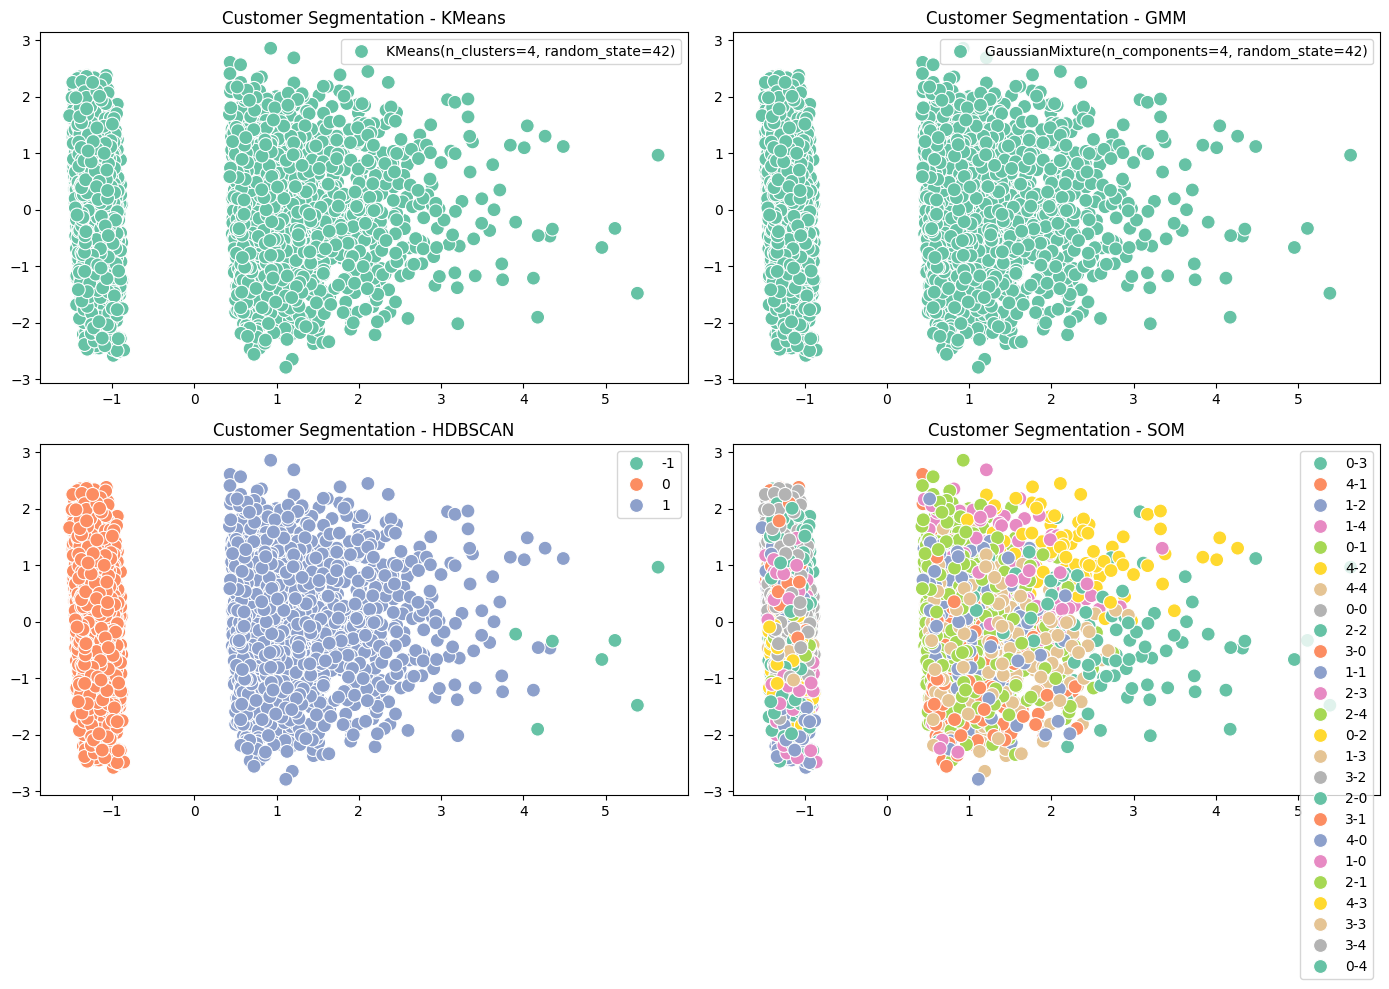

In [74]:
pca = PCA(n_components=3)
rfm_pca = pca.fit_transform(rfm_scaled)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
algos = ['k_means_label', 'gmm_label', 'hdbscan_label', 'SOM_Cluster']
titles = ['KMeans', 'GMM', 'HDBSCAN', 'SOM']

for i, ax in enumerate(axes.flat):
    sns.scatterplot(x=rfm_pca[:, 0], y=rfm_pca[:, 1],
                    hue=df[algos[i]], palette='Set2', ax=ax, s=100)
    ax.set_title(f"Customer Segmentation - {titles[i]}")
    ax.legend(loc='best')

plt.tight_layout()
plt.show()

In [73]:
pca_loadings = pd.DataFrame(pca.components_, columns=rfm.columns, index=['Principal Component 1', 'Principal Component 2','Principal Component 3'])
display(pca_loadings)

plt.figure(figsize=(8, 4))
sns.heatmap(pca_loadings, annot=True, cmap='viridis')
plt.title('PCA Loadings')
plt.show()

ValueError: Shape of passed values is (2, 6), indices imply (3, 6)